## Linear Regression
This is the file where the Linear Regression Model of the Price Prediction Project is implemented. Work here done by Thies


In [12]:
%matplotlib inline
# imports and such
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
data = pd.read_csv('processed-data/clean-listings.csv')
print(data.shape)
print(data.columns)

(3627, 34)
Index(['listing_id', 'latitude', 'longitude', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'reviews_per_month'],
      dtype='object')


In [ ]:
target_column = 'price'

X = data.drop(columns=[target_column])
y = data[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


               listing_id  latitude  longitude  accommodates  bathrooms  \
1462   632682403112950941 -0.528553   0.760936      0.261062   1.276752   
3090  1284113928583755359  1.016941   0.858200      1.079447  -0.424489   
528              22814686 -0.561383   0.808151      5.171372   4.679234   
176               6851460  0.293974   0.169168     -0.557323  -0.424489   
929              45689363  0.613707   0.726941      0.670254   1.276752   

      bedrooms      beds  minimum_nights  maximum_nights  \
1462  0.453092  0.061387        0.319069       -0.416434   
3090  1.323519  0.701183       -0.709549       -0.416434   
528   4.805225  6.459353        0.284782        1.499776   
176  -1.287761 -0.578410       -0.709549        1.499776   
929   0.453092  0.061387        0.353357       -0.655961   

      minimum_minimum_nights  ...  estimated_occupancy_l365d  \
1462                0.376031  ...                  -0.930146   
3090               -0.709041  ...                  -0.930146

(2901,)


(array([442., 567., 505., 580., 484., 348., 185., 126.,  86.,  73.,  47.,
         49.,  19.,  16.,  19.,   8.,   5.,  11.,   2.,   9.,   8.,   4.,
          3.,   7.,   5.,   4.,   0.,   1.,   0.,   0.,   1.,   2.,   2.,
          3.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   2.,   1.]),
 array([  25.  ,   64.62,  104.24,  143.86,  183.48,  223.1 ,  262.72,
         302.34,  341.96,  381.58,  421.2 ,  460.82,  500.44,  540.06,
         579.68,  619.3 ,  658.92,  698.54,  738.16,  777.78,  817.4 ,
         857.02,  896.64,  936.26,  975.88, 1015.5 , 1055.12, 1094.74,
        1134.36, 1173.98, 1213.6 , 1253.22, 1292.84, 1332.46, 1372.08,
        1411.7 , 1451.32, 1490.94, 1530.56, 1570.18, 1609.8 , 1649.42,
        1689.04, 1728.66, 1768.28, 1807.9 , 1847.52, 1887.14, 1926.76,
        1966.38, 2006.  ]),
 <BarContainer object of 50 artists>)

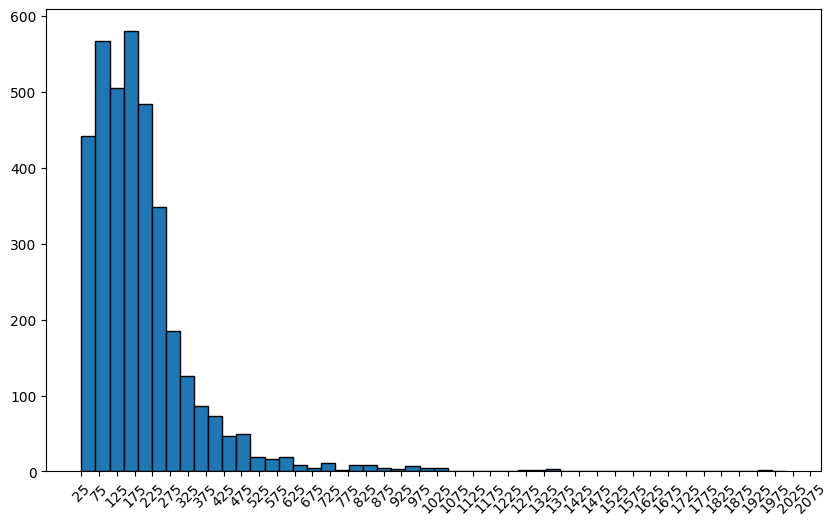

In [31]:
print(y_train.shape)
# price distribution
plt.figure(figsize=(10, 6))
plt.xticks(np.arange(int(y.min()), int(y.max()) + 100, 50), rotation=45)
plt.hist(y, bins=50, edgecolor='black')


In [33]:
regr = LinearRegression()
regr.fit(X_train, y_train)
print(regr.score(X_test, y_test))

0.003942211957221553


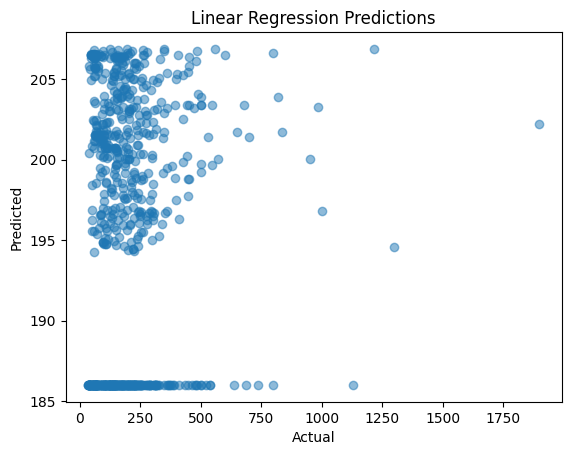

In [ ]:
# What we currently see is that the score of the model basically implies its just guessing the average price.
y_pred = regr.predict(X_test)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Predictions")
plt.show()